In [1]:
import pickle
import os
from pathlib import Path
import sys

In [2]:
# current dir
notebooks_dir = Path().resolve()
# repo root
repo_root = notebooks_dir.parent.parent
# src
src_path = repo_root / "src"
# bsard data path
bsard_data_path = repo_root / "data" / "BSARD_dataset"

# insert src in sys.path for importing modules
sys.path.insert(0, str(src_path))


In [3]:
with open(os.path.join(bsard_data_path, "intermediate", 'G_semantic.pkl'), 'rb') as f:
    G_semantic = pickle.load(f)

In [4]:
G_semantic.nodes["25.14.1.52"]

{'node_type': 'Article',
 'text': "§ 1er. La FSMA peut enjoindre à un prêteur ou à un intermédiaire de crédit de se conformer aux dispositions du livre VII, titre 4, chapitre 4, à l'exception de l'article VII.183, § 5, 4°ou des arrêtés et règlements pris pour son exécution, dans le délai que la FSMA détermine.§ 2. Sans préjudice des autres mesures prévues par le présent livre ou par le livre VII, titre 4, chapitre 4, si la personne à laquelle elle a adressé une injonction en application du § 1er reste en défaut de se conformer à l'injonction à l'expiration du délai qui lui a été imparti, la FSMA peut, la personne ayant pu faire valoir ses moyens de défense :1° rendre publique sa position quant à l'infraction ou à la défaillance en question. Les frais de cette publication sont à charge du prêteur ou de l'intermédiaire de crédit concerné;2° imposer le paiement d'une astreinte qui ne peut être supérieure, dans le cas des prêteurs, à 5.000 euros par jour de retard ni, au total, par infract

In [5]:
import networkx as nx  # NetworkX for graph handling
from chromadb import Client  # ChromaDB client for vector operations


def add_semantic_edges(G: nx.DiGraph, n: int) -> nx.DiGraph:
    """
    For each node of type 'article' in graph G, find the top-n most similar
    article nodes based on their 'embedding' attribute, and add edges
    connecting them with a 'semantic_similarity' relation.
    """
    # If G isn't directed, convert it to a DiGraph
    if not isinstance(G, nx.DiGraph):
        G = nx.DiGraph(G)

    # Initialize the ChromaDB client (in-memory by default)
    client = Client()
    # Create or get a collection named 'articles' to store embeddings
    collection = client.create_collection(name="Articles")

    # Gather all article-type nodes
    article_nodes = [
        node
        for node, data in G.nodes(data=True)
        if data.get("node_type") == "Article"
    ]

    print(f"Number of article nodes: {len(article_nodes)}")  # Debug: print number of article nodes


    # Map string IDs (for Chroma) back to original node keys
    id_map = {str(node): node for node in article_nodes}
    # Extract embeddings in the same order as article_nodes
    embeddings = [G.nodes[node]["embedding"] for node in article_nodes]

    print(embeddings[0])  # Debug: print first embedding
    print((len(embeddings)))  # Debug: print number of embeddings

    # Add embeddings to the ChromaDB collection
    collection.add(
        embeddings=embeddings,
        ids=list(id_map.keys()),
        #metadatas=[{} for _ in article_nodes],  # optional metadata placeholder
    )

    # For each article, query for the top-n similar embeddings
    for str_id in id_map.keys():
        # Retrieve the original embedding from the graph
        embedding = G.nodes[id_map[str_id]]["embedding"]
        # Query ChromaDB for n+1 results (including itself)
        results = collection.query(
            query_embeddings=[embedding],
            n_results=n + 1,
        )
        # Extract the list of similar IDs
        similar_ids = results["ids"][0]

        # Create edges for each similar article (excluding self)
        for sim_str in similar_ids:
            if sim_str == str_id:
                continue  # skip self-match
            # Map back to original node keys
            src = id_map[str_id]
            dst = id_map[sim_str]
            # Add an undirected edge with a semantic similarity label
            G.add_edge(src, dst, relation="semantic_similarity")

    return G


# Example of usage:
# G = nx.Graph()
# G.add_node(1, type="article", embedding=[0.1, 0.2, ...])
# G.add_node(2, type="article", embedding=[0.3, 0.4, ...])
# ... add more nodes ...
# G = add_semantic_edges(G, n=5)
# Now G contains edges between each article and its top-5 semantic neighbors


In [6]:
G_pretraining = add_semantic_edges(G_semantic, 3)

Number of article nodes: 22625
[-0.006365415, 0.011672591, -0.030560708, -0.0014849487, -0.046756506, -0.0072449017, 0.06577218, 0.02317325, -0.0067556025, 0.014162728, -0.009448052, -0.0102586895, -0.02208003, 0.012046797, 0.019954184, -0.01705935, 0.039248336, 0.029798634, -0.01957287, -0.028551828, -0.04128564, -0.06194378, -0.021671802, 0.039595228, 0.004332404, -0.02076099, 0.03518242, 0.021258134, 0.031787895, -0.00016106453, 0.03703076, -0.013665759, 0.052258775, -0.060145035, -0.02060499, -0.07419223, 7.3149975e-05, -0.012348542, -0.047265094, 0.06262648, 0.04199956, -0.047716685, 0.020279674, -0.02327837, 0.018944105, -0.038939968, -0.021837413, -0.022231646, -0.025781002, 0.029465105, 0.028990204, 0.017913545, 0.051208925, -0.03904337, -0.060339358, 0.0031292744, -0.01580353, 0.0034206137, -0.0056894477, -0.0057556103, -0.020273987, -0.007487863, -0.015228638, -0.010032098, 0.018107435, -0.02227995, 0.013702314, 0.022425594, -0.025577515, -0.03789098, 0.024082085, -0.01233202

In [7]:
import matplotlib.pyplot as plt  # For visualization

def visualize_node_1hop(G: nx.DiGraph, node_id: str, figsize=(12, 8)):
    """
    Visualize a node and its 1‑hop neighborhood in a hierarchy graph.

    Nodes are colored by their 'level' attribute:
      - Central node: red
      - Act: gold
      - Book: orange
      - Title: lightblue
      - Chapter: green
      - Section: teal
      - Article: purple

    Edges are drawn and labeled according to their 'relation' attribute:
      - CONTAINS: black, label="contains"
      - BELONGS_TO: gray, label="belongs to"
    """
    # Gather the node and its immediate predecessors & successors
    preds = list(G.predecessors(node_id))
    succs = list(G.successors(node_id))
    sub_nodes = {node_id, *preds, *succs}
    subG = G.subgraph(sub_nodes)

    plt.figure(figsize=figsize)
    # Force a consistent layout for clarity
    pos = nx.spring_layout(subG, k=1.0, iterations=50, seed=42)

    # Color mapping for levels
    level_colors = {
        "Act": "gold",
        "Book": "orange",
        "Title": "lightblue",
        "Chapter": "green",
        "Section": "teal",
        "Article": "purple"
    }

    # Draw all nodes, colored by level
    for level, color in level_colors.items():
        nodes_of_level = [
            n for n, attrs in subG.nodes(data=True)
            if attrs.get("level") == level and n != node_id
        ]
        nx.draw_networkx_nodes(
            subG, pos,
            nodelist=nodes_of_level,
            node_color=color,
            node_size=1200,
            label=level
        )

    # Draw the central node on top
    nx.draw_networkx_nodes(
        subG, pos,
        nodelist=[node_id],
        node_color="red",
        node_size=1500,
        label="Central"
    )

    # Draw edges by relation type
    relation_styles = {
        "CONTAINS":    {"color": "black", "label": "contains"},
        "BELONGS_TO":  {"color": "gray",  "label": "belongs to"}
    }
    # We'll collect labels separately so they don't overlap too badly
    edge_labels = {}

    for (u, v, attrs) in subG.edges(data=True):
        rel = attrs.get("relation")
        style = relation_styles.get(rel, {})
        nx.draw_networkx_edges(
            subG, pos,
            edgelist=[(u, v)],
            edge_color=style.get("color", "black"),
            arrows=True,
            arrowsize=20,
            connectionstyle="arc3,rad=0.1"
        )
        # position label near the middle of the edge
        edge_labels[(u, v)] = style.get("label", rel.lower())

    # Draw edge labels
    nx.draw_networkx_edge_labels(
        subG, pos,
        edge_labels=edge_labels,
        font_size=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        label_pos=0.5
    )

    # Draw node labels (just show the node_id or you could use attrs['label'])
    labels = {n: n.split("|", 1)[-1] for n in subG.nodes()}
    nx.draw_networkx_labels(subG, pos, labels, font_size=8)

    # Add a legend for node colors
    handles = []
    for level, color in level_colors.items():
        handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                  label=level,
                                  markerfacecolor=color, markersize=10))
    handles.append(plt.Line2D([0], [0], marker='o', color='w',
                              label="Central", markerfacecolor='red', markersize=10))
    plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1, 1))

    plt.title(f"1‑hop neighborhood of node: {node_id}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

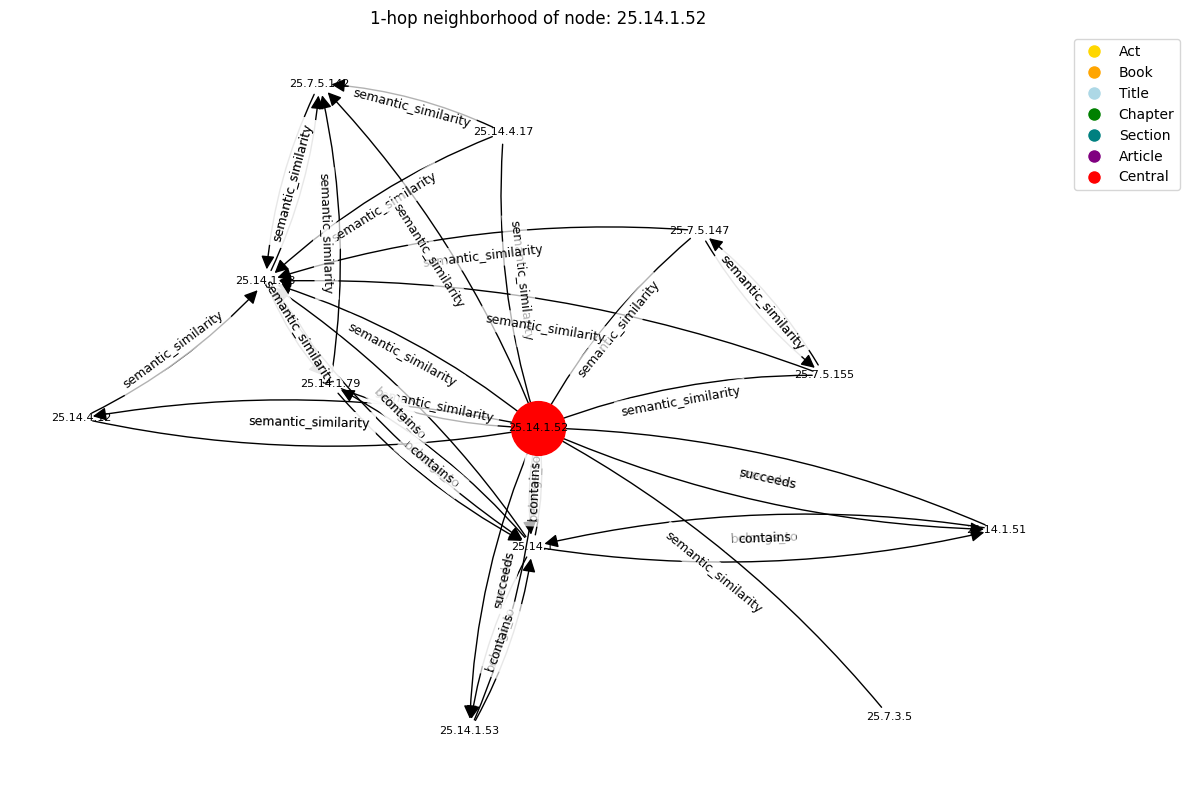

In [8]:
visualize_node_1hop(G_pretraining, "25.14.1.52")